In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean data
df = pd.read_csv("../data/processed/jobs_cleaned.csv")

print("Data loaded!")
print("Shape:", df.shape)

Data loaded!
Shape: (61951, 14)


In [2]:
#top 10 most wanted jobs
from collections import Counter
import ast

# Count every skill across all jobs
all_skills = []

for skills in df['skills']:
    try:
        skill_list = ast.literal_eval(skills)
        all_skills.extend(skill_list)
    except:
        pass

# Count and get top 10
skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(10), 
                           columns=['skill', 'count'])

print(top_skills)

        skill  count
0         sql  31005
1       excel  19778
2      python  18792
3    power_bi  17420
4     tableau  16822
5           r  11341
6         sas   5316
7  powerpoint   4410
8        word   4364
9       azure   3886


/var/folders/dg/n3npy9qd6m7fm_j210vlt_240000gn/T/ipykernel_1909/2858037177.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills,


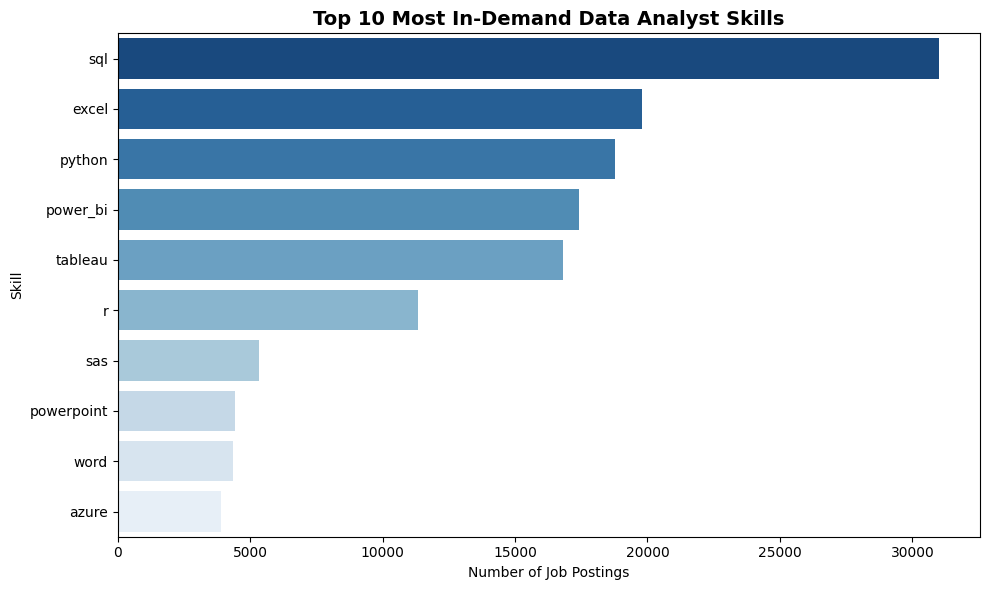

Chart saved!


In [3]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_skills, 
            x='count', 
            y='skill', 
            palette='Blues_r')

plt.title('Top 10 Most In-Demand Data Analyst Skills', 
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')

plt.tight_layout()
plt.savefig('../data/processed/top_skills.png')
plt.show()

print("Chart saved!")

/var/folders/dg/n3npy9qd6m7fm_j210vlt_240000gn/T/ipykernel_1909/4185999751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values,


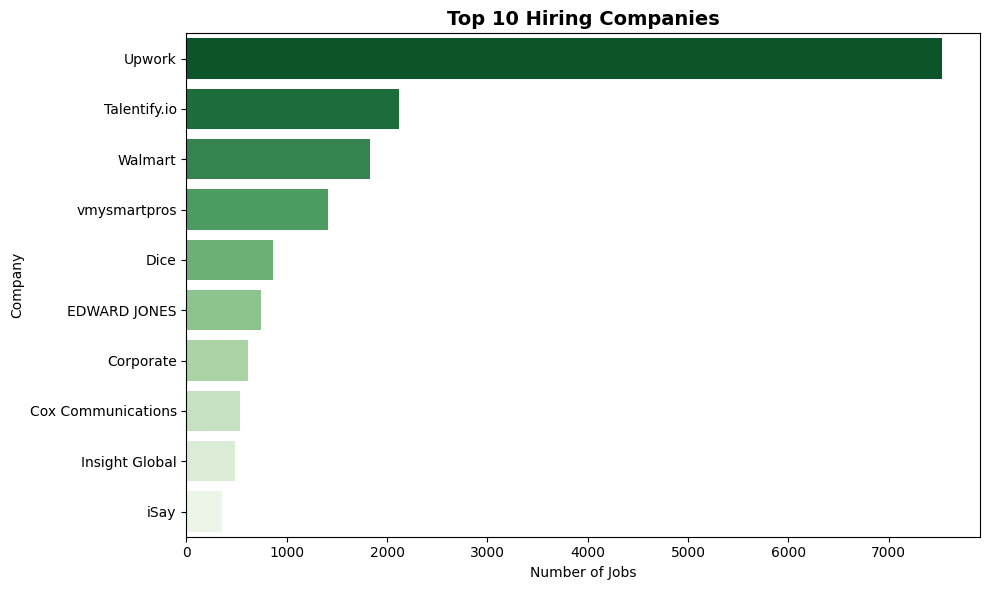

In [4]:
#top 10 hiring companies
plt.figure(figsize=(10, 6))

top_companies = df['company_name'].value_counts().head(10)

sns.barplot(x=top_companies.values, 
            y=top_companies.index, 
            palette='Greens_r')

plt.title('Top 10 Hiring Companies', 
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('Company')

plt.tight_layout()
plt.savefig('../data/processed/top_companies.png')
plt.show()

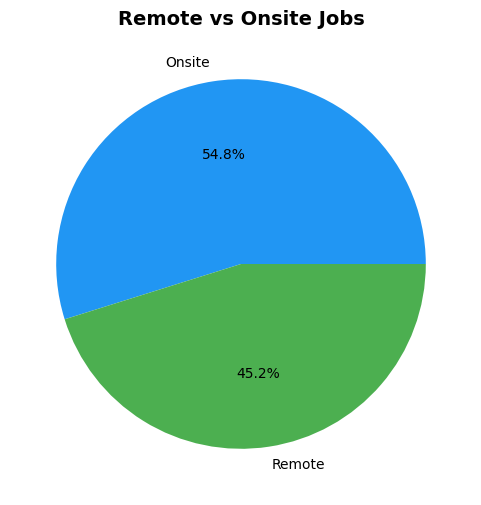

In [5]:
#remote vs onsite
plt.figure(figsize=(6, 6))

remote_counts = df['work_from_home'].value_counts()
labels = ['Onsite', 'Remote']

plt.pie(remote_counts.values, 
        labels=labels, 
        autopct='%1.1f%%',
        colors=['#2196F3', '#4CAF50'])

plt.title('Remote vs Onsite Jobs', 
          fontsize=14, fontweight='bold')

plt.savefig('../data/processed/remote_vs_onsite.png')
plt.show()

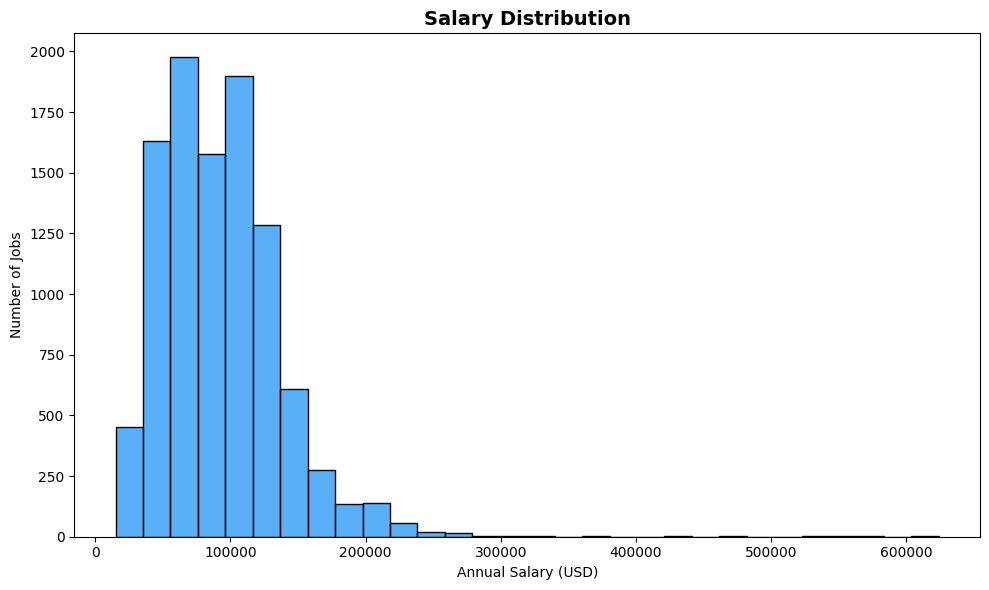

In [6]:
#salary distribution
plt.figure(figsize=(10, 6))

# Only rows that have salary
df_salary = df[df['salary_standardized'].notna()]

sns.histplot(df_salary['salary_standardized'], 
             bins=30, 
             color='#2196F3')

plt.title('Salary Distribution', 
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Salary (USD)')
plt.ylabel('Number of Jobs')

plt.tight_layout()
plt.savefig('../data/processed/salary_distribution.png')
plt.show()